# NB08 — EDA Séries Temporelles

**Projet :** FR_Santiago_caminos  
**Phase :** 3 — Feature Engineering  
**Input :** `data/processed/flux_consolide.parquet` + `params_comportementaux.csv`  
**Output :** `data/processed/gr65_compartiments.parquet` + `data/processed/priors_comportementaux.json`

**Objectif :** Caractériser la dynamique spatio-temporelle des flux pèlerins sur le GR65
en vue de la calibration du modèle à compartiments (NB09).

**Séquence :**
1. `[CHARGEMENT]` — flux consolidé + paramètres comportementaux
2. `[COMPARTIMENTS]` — définition de la chaîne GR65, filtrage et pivot
3. `[SÉRIES TEMPORELLES]` — visualisation annuelle par compartiment, annotations structurelles
4. `[TRANSITIONS]` — ratios de transition observés α(C_i → C_{i+1}, t)
5. `[SJPP MENSUEL]` — profil intra-annuel, saisonnalité, dimensions
6. `[PRIORS COMPORTEMENTAUX]` — extraction depuis params_comportementaux.csv
7. `[SYNTHÈSE EDA]` — tableau de bord récapitulatif, export


## 0. Imports et chemins

In [1]:
import json
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings("ignore", category=UserWarning)

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:,.0f}".format)
pd.set_option("display.width", 120)

# Style matplotlib
plt.rcParams.update({
    "figure.dpi":      120,
    "figure.facecolor": "white",
    "axes.spines.top":  False,
    "axes.spines.right":False,
    "font.size":        10,
})

_here = Path().resolve()
ROOT  = _here if (_here / "data").exists() else _here.parent
assert (ROOT / "data").exists(), f"data/ introuvable depuis {_here}"

DATA_PROCESSED = ROOT / "data" / "processed"
FIGURES_DIR    = ROOT / "reports" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print(f"ROOT           : {ROOT}")
print(f"DATA_PROCESSED : {DATA_PROCESSED}")
print(f"FIGURES_DIR    : {FIGURES_DIR}")


ROOT           : C:\Users\cello\Desktop\FR_Santiago_caminos
DATA_PROCESSED : C:\Users\cello\Desktop\FR_Santiago_caminos\data\processed
FIGURES_DIR    : C:\Users\cello\Desktop\FR_Santiago_caminos\reports\figures


## 1. Chargement des données consolidées

Deux sources issues de NB07 :
- `flux_consolide.parquet` — observations de flux multi-sources (annuel + mensuel SJPP)
- `params_comportementaux.csv` — paramètres comportementaux AFCC/ACIR/Decazeville


In [2]:
# ── flux_consolide ──────────────────────────────────────────────────────────────
_flux_path = DATA_PROCESSED / "flux_consolide.parquet"
assert _flux_path.exists(), f"Lancer NB07 avec dry_run=False d'abord : {_flux_path}"

df = pd.read_parquet(_flux_path, engine="fastparquet")
df["annee"] = pd.to_numeric(df["annee"], errors="coerce").astype("Int64")
df["mois"]  = pd.to_numeric(df["mois"],  errors="coerce").astype("Int64")

print(f"flux_consolide : {df.shape}")
print(f"  Colonnes clés  : {[c for c in df.columns if c in ['site_code','annee','mois','comptage','voie_id','type_source','fiabilite','flag_qualite']]}")
print(f"  Sites          : {sorted(df['site_code'].dropna().unique().tolist())}")
print(f"  Années         : {sorted(df['annee'].dropna().unique().tolist())}")
print(f"  Sources        : {df['_source_key'].unique().tolist()}")

# ── params comportementaux ───────────────────────────────────────────────────────
_params_path = DATA_PROCESSED / "params_comportementaux.csv"
assert _params_path.exists(), f"Lancer NB07 avec dry_run=False d'abord : {_params_path}"

df_params = pd.read_csv(_params_path, encoding="utf-8-sig")
print(f"\nparams_comportementaux : {df_params.shape}")
print(f"  Colonnes : {list(df_params.columns[:8])} ...")


flux_consolide : (428, 37)
  Colonnes clés  : ['annee', 'mois', 'site_code', 'voie_id', 'type_source', 'comptage', 'fiabilite', 'flag_qualite']
  Sites          : ['Felzins', 'Labastide-Marnhac', 'Labastide-Murat', 'Limogne-en-Quercy', 'PM_ARL_AYGUESVIVES', 'PM_ARL_GIMONT', 'PM_ARL_LODEVE', 'PM_ARL_LUNAS', 'PM_ARL_REVEL', 'PM_ARL_STGUILHEM', 'PM_ARL_STSERNIN', 'PM_PIE_LOURDES', 'PM_PIE_STBERTRAND', 'PM_PUY_BARDIGUES', 'PM_PUY_CONQUES', 'PM_PUY_FELZINS', 'PM_PUY_FIGEAC_AMONT', 'PM_PUY_LAUZERTE', 'PM_PUY_SAUGUES', 'PM_PUY_STCHRISTO', 'PM_SJC', 'PM_SJPP', 'PM_TOU_CHATELLERAULT', 'PM_TOU_STJEANANGELY', 'PM_TOU_STMAURE', 'PM_VEZ_PERIGUEUX', 'PM_VEZ_STLEONARD', 'PM_VEZ_VEZELAY', 'SJPP', 'Saint-Chignes (Gramat)']
  Années         : [2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]
  Sources        : ['flux_principal', 'sjpp_flux', 'lot_ecocompteurs', 'ot_decazeville_2018']

params_comportementaux : (422, 73)
  Colonnes : ['parametre_id', 'nom', 'valeur', 'unite', 

## 2. Définition des compartiments GR65

La chaîne GR65 Le Puy → SJPP est découpée en 8 compartiments identifiables dans le dataset,
chacun associé à un ou plusieurs `site_code`.

**Logique de sélection :**
- Sites `voie_id == "V01"` (GR65) de `01_data_long`, complétés par les éco-compteurs Lot
- Plusieurs sites pour un compartiment × année → on retient le maximum (éco-compteur > accueil)
- Sites OT ponctuels (`PM_TOU_*`, `PM_PIE_*`, `PM_ARL_*`) : exclus du modèle GR65,
  conservés dans `df` pour analyses transversales uniquement

**Distances indicatives** depuis Le Puy-en-Velay, à pas de pèlerin (GR65).

> ⚠️ **C1_LePuy — biais de mesure à connaître**  
> `PM_PUY_STCHRISTO` désigne le compteur de **Saint-Christophe-sur-Dolaison**,
> village traversé par le GR65 à **10 km** du Puy. À cette distance,
> aucun pèlerin n'a encore abandonné — mais le compteur enregistre **tous les
> utilisateurs du sentier** : randonneurs locaux, journées depuis Le Puy, sorties
> scolaires. Il n'est pas pèlerin-spécifique.  
> Cela explique le comptage 2024 = **35 850 passages** alors que C2_Saugues
> (57 km) n'en affiche que 20 014 : les ~15 000 passages "supplémentaires" sont
> vraisemblablement des usagers locaux du GR65, non des pèlerins de Compostelle.
> Deux facteurs structurels amplifient probablement ce biais :
> - **Campagne "Pèlerin d'un jour" (OT du Puy) :** l'Office de Tourisme commercialise
>   un package pique-nique avec retour en bus depuis Saint-Christophe. Ces sorties
>   d'une journée traversent le compteur STCHRISTO sans générer de flux vers Saugues.
> - **Difficulté de l'étape Montbonnet → Saugues :** c'est l'étape la plus exigeante
>   du GR65 auvergnat (>1 000 m D+, passages techniques). Des navettes permettant
>   de la contourner existent ; des marcheurs partis depuis Le Puy peuvent s'arrêter
>   avant Saugues ou emprunter la navette sans passer devant l'éco-compteur de Saugues.
>
> Sa couverture lacunaire (3/8 ans : 2018, 2019, 2024) en fait un compartiment
> d'ancrage fragile. **C8_SJPP sera l'ancre de calibration principale** — ce compteur
> enregistre les pèlerins ayant reçu leur compostelle, c'est-à-dire
> ayant effectivement parcouru les 100 derniers km à pied.


In [3]:
# ── Définition des compartiments GR65 ───────────────────────────────────────────
COMPARTIMENTS: dict[str, dict] = {
    "C1_LePuy":   {"sites": ["PM_PUY_STCHRISTO"],                    "nom": "Départ Le Puy",        "km_depuis_puy": 0,   "flag_rc05": False},
    "C2_Saugues": {"sites": ["PM_PUY_SAUGUES"],                      "nom": "Saugues",              "km_depuis_puy": 57,  "flag_rc05": True},
    "C3_Conques": {"sites": ["PM_PUY_CONQUES"],                      "nom": "Conques",              "km_depuis_puy": 160, "flag_rc05": True},
    "C4_Figeac":  {"sites": ["PM_PUY_FIGEAC_AMONT"],                "nom": "Figeac",               "km_depuis_puy": 240, "flag_rc05": False},
    "C5_Lot":     {"sites": ["PM_PUY_FELZINS", "Felzins"],          "nom": "Entrée Lot (Felzins)", "km_depuis_puy": 288, "flag_rc05": False},
    "C6_Cahors":  {"sites": ["Labastide-Marnhac"],                   "nom": "Sortie Cahors",        "km_depuis_puy": 370, "flag_rc05": False},
    "C7_Moissac": {"sites": ["PM_PUY_LAUZERTE", "PM_PUY_BARDIGUES"],"nom": "Après Moissac",       "km_depuis_puy": 450, "flag_rc05": False},
    "C8_SJPP":    {"sites": ["PM_SJPP"],                             "nom": "SJPP",                 "km_depuis_puy": 755, "flag_rc05": False},
}

ANNEES_PROJET    = list(range(2017, 2025))
COVID_ANNEES     = {2020, 2021}
JACQUAIRE_ANNEES = {2021}

# ── Extraction vectorisée (merge, sans iterrows) ─────────────────────────────────
df_annuel = df[
    df["annee"].isin(ANNEES_PROJET)
    & (df["mois"].isna() | (df["_source_key"] != "sjpp_flux"))
    & df["comptage"].notna()
].copy()

# Table de correspondance site_code → compartiment
_sites_map = pd.DataFrame([
    {"site_code": site, "compartiment": cid,
     "nom": cfg["nom"], "km_depuis_puy": cfg["km_depuis_puy"], "flag_rc05_comp": cfg["flag_rc05"]}
    for cid, cfg in COMPARTIMENTS.items()
    for site in cfg["sites"]
])

df_comp = (
    df_annuel
    .merge(_sites_map, on="site_code", how="inner")
    [["compartiment", "nom", "km_depuis_puy", "flag_rc05_comp",
      "site_code", "annee", "comptage", "fiabilite", "flag_qualite", "_source_key"]]
    .sort_values(["compartiment", "annee"])
    .reset_index(drop=True)
)

# Plusieurs sites pour un même compartiment × année → garder le max
df_comp = (
    df_comp
    .groupby(["compartiment", "nom", "km_depuis_puy", "annee", "flag_qualite"], dropna=False)
    ["comptage"].max()
    .reset_index()
)

print(f"df_comp : {df_comp.shape}")
print()
for cid, cfg in COMPARTIMENTS.items():
    sub  = df_comp[df_comp["compartiment"] == cid]
    ok   = sorted(sub[sub["comptage"].notna()]["annee"].tolist())
    rc05 = "  🚩 RC_05" if cfg["flag_rc05"] else ""
    print(f"  {cid:12s}  {cfg['nom']:28s}  {len(ok)}/8 ans  {ok}{rc05}")


df_comp : (44, 6)

  C1_LePuy      Départ Le Puy                 3/8 ans  [2018, 2019, 2024]
  C2_Saugues    Saugues                       7/8 ans  [2017, 2018, 2019, 2021, 2022, 2023, 2024]  🚩 RC_05
  C3_Conques    Conques                       8/8 ans  [2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]  🚩 RC_05
  C4_Figeac     Figeac                        6/8 ans  [2017, 2018, 2019, 2021, 2023, 2024]
  C5_Lot        Entrée Lot (Felzins)          4/8 ans  [2017, 2022, 2023, 2024]
  C6_Cahors     Sortie Cahors                 2/8 ans  [2023, 2024]
  C7_Moissac    Après Moissac                 6/8 ans  [2018, 2019, 2021, 2022, 2023, 2024]
  C8_SJPP       SJPP                          8/8 ans  [2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]


## 3. Séries temporelles par compartiment

Flux annuel 2017-2024 pour chaque compartiment GR65.

Repères visuels :
- Zone rouge 2020 — COVID confinements, fermeture quasi-totale des chemins
- Zone orange 2021 — COVID restrictions + Année Jacquaire (effet ambivalent)
- Marqueur ⚠ rouge — observations flaggées `suspect_RC05_doublon_2022`

**Lecture des graphiques :**

Les séries révèlent cinq dynamiques distinctes, visibles dans les données (cf. tableau §4) :

**C3_Conques (série la plus complète et la plus régulière, 8/8 ans)**  
Tendance nette à la hausse : 17 315 (2017) → 23 230 (2023), soit +34% sur la fenêtre hors COVID.
C'est le compartiment de référence pour la modélisation — couverture complète, comptage pèlerin-spécifique
(accueil Sainte-Foy), pas de biais de fréquentation locale.

**C2_Saugues (7/8 ans, RC_05 2022 flaggé)**  
Progression similaire à Conques jusqu'en 2021, puis anomalie 2022 (valeur identique à Conques = 22 457).
2023-2024 reprend normalement. La série sans 2022 est exploitable.

**C8_SJPP (série la plus longue, 8/8 ans)**  
Effondrement 2020 (10 014 vs ~58 000 en temps normal) et rebond asymétrique 2021 (20 586 seulement,
malgré l'Année Jacquaire — les restrictions COVID ont visiblement primé). Retour au niveau pré-COVID
en 2022 (52 926) puis stabilisation 2023-2024 (~58 000).

**C1_LePuy (3/8 ans)**  
2024 = 35 850, valeur nettement supérieure à C2_Saugues 2024 (20 014). Le biais de mesure
documenté en §2 explique cet écart : STCHRISTO capte l'intégralité du trafic GR65
(randonneurs locaux, pèlerins d'un jour, scolaires), pas uniquement les pèlerins se
rendant à Compostelle. Les hypothèses H1/H2 (§2) sont en cours d'investigation.

**C5_Lot et C6_Cahors (séries courtes, 2022+)**  
Felzins montre une progression régulière 2022-2024 (18 800 → 20 270). Labastide-Marnhac
suit à ~16 000-17 600, cohérent avec un α(C5→C6) ≈ 0.85 (15% de sortie entre Felzins et Cahors).


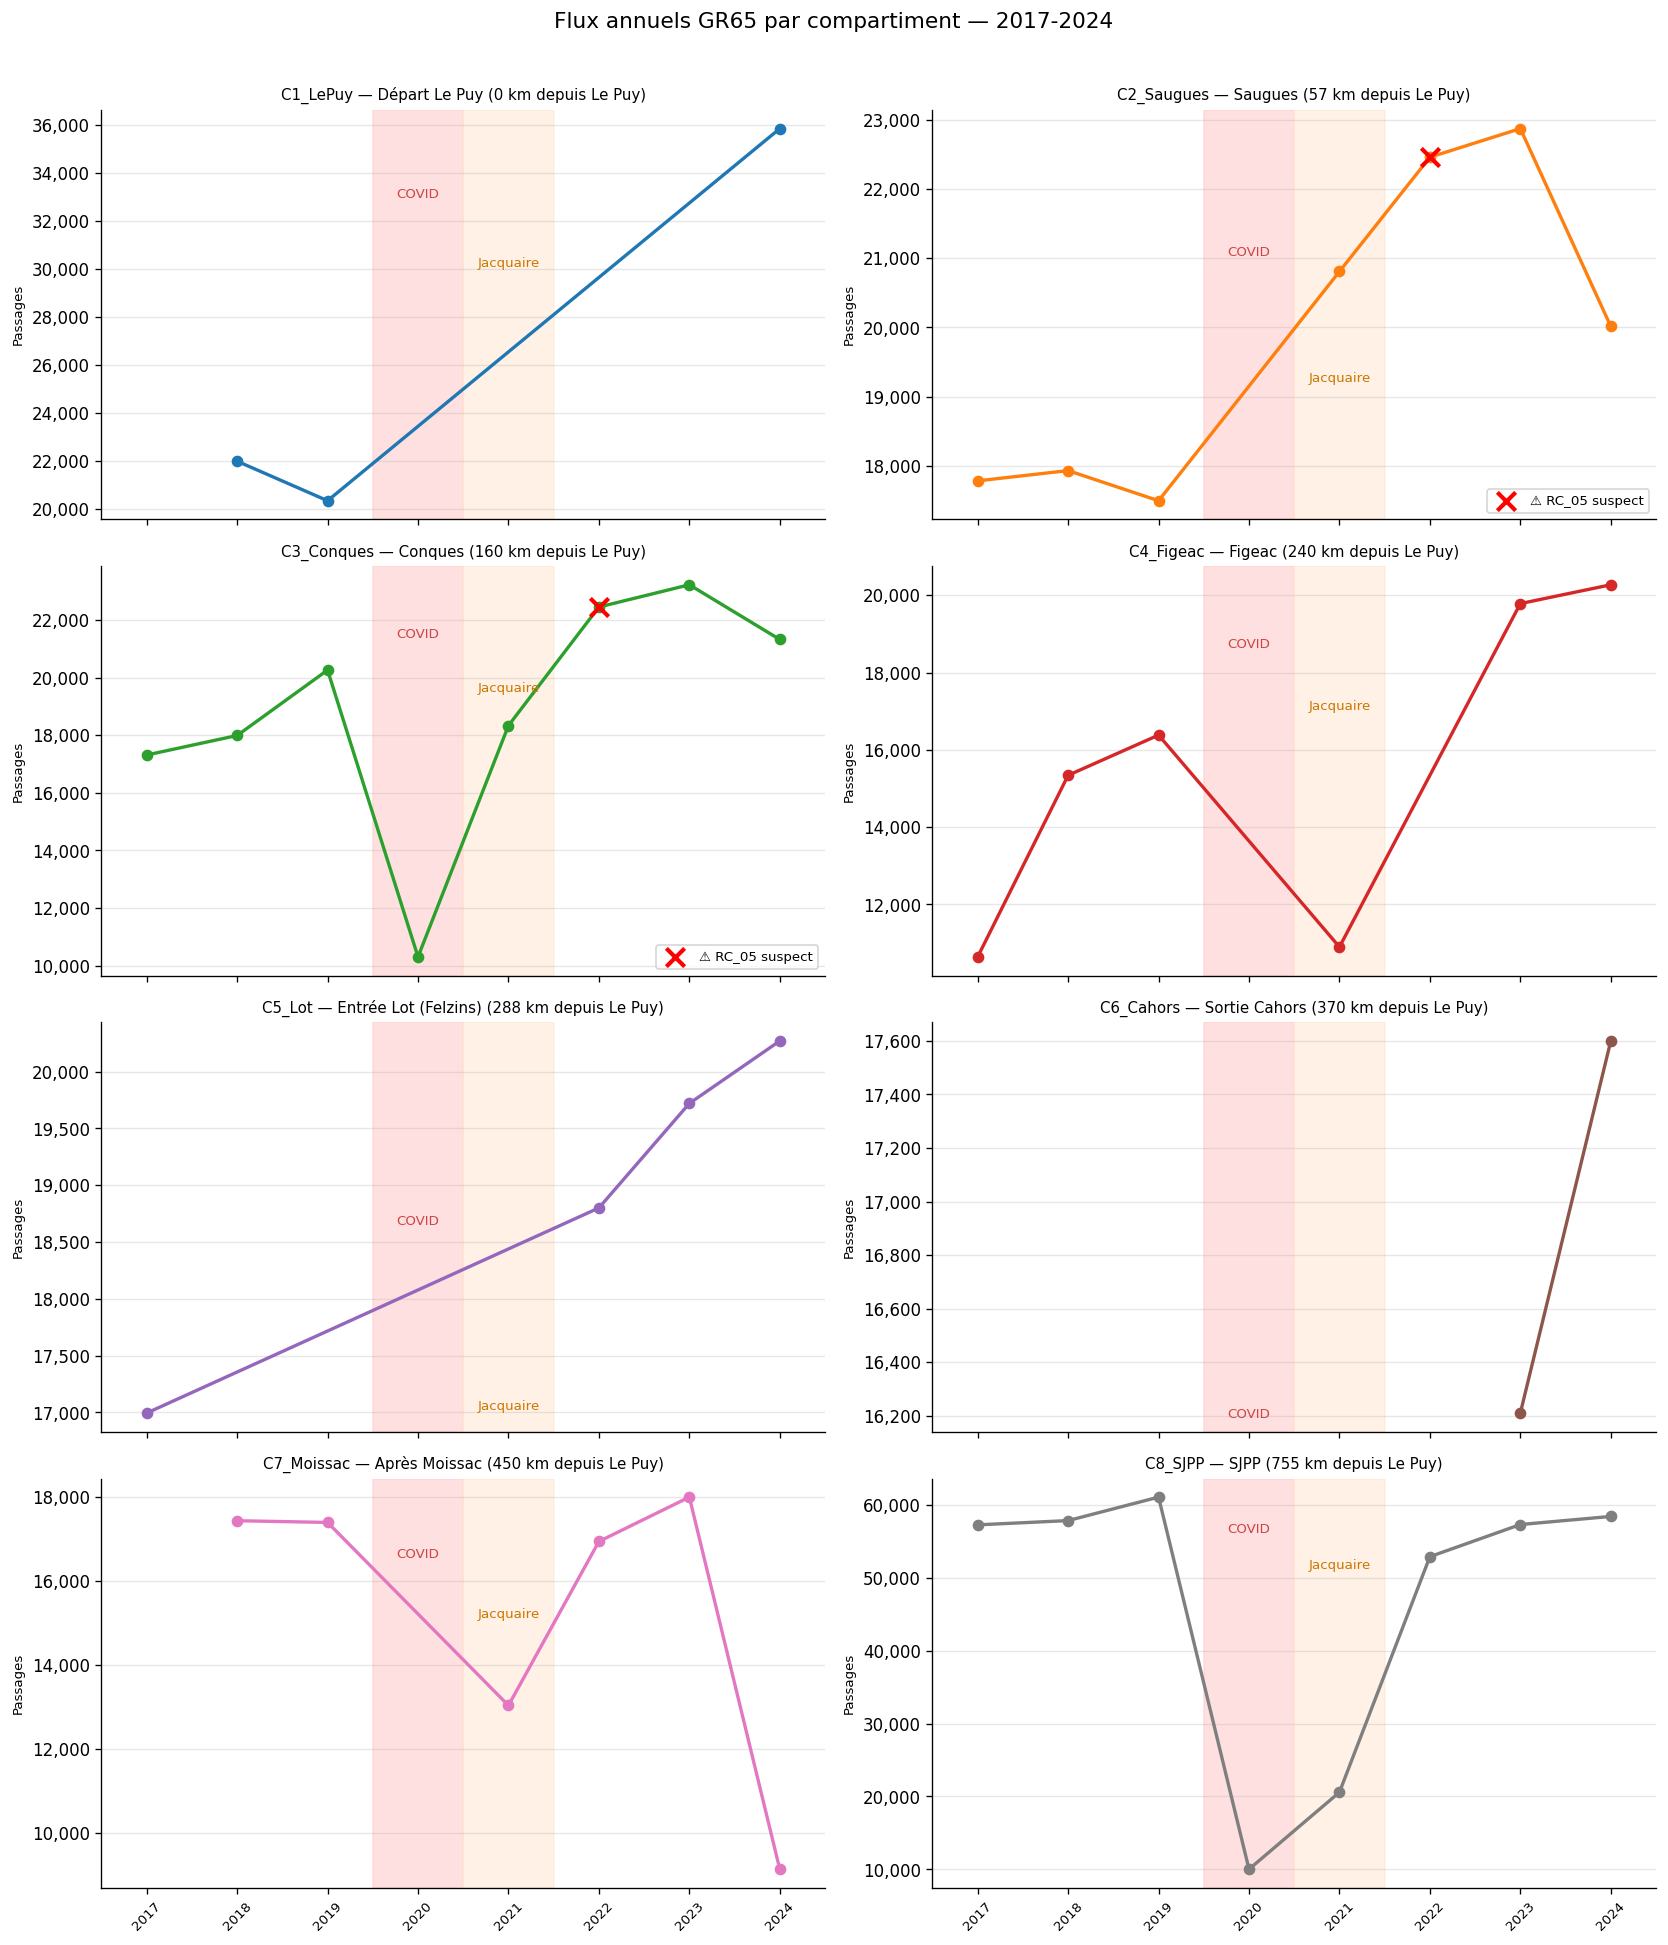

Figure sauvegardée : reports/figures/nb08_flux_compartiments.png


In [4]:
fig, axes = plt.subplots(4, 2, figsize=(14, 16), sharex=True)
axes = axes.flatten()
COLORS = plt.cm.tab10.colors

for idx, (comp_id, cfg) in enumerate(COMPARTIMENTS.items()):
    ax = axes[idx]
    sub = df_comp[df_comp["compartiment"] == comp_id].sort_values("annee")

    # Zones COVID / Jacquaire
    ax.axvspan(2019.5, 2020.5, color="#ffcccc", alpha=0.6, zorder=0)
    ax.axvspan(2020.5, 2021.5, color="#ffe5cc", alpha=0.5, zorder=0)

    if not sub.empty:
        # Série principale
        ax.plot(sub["annee"], sub["comptage"],
                marker="o", linewidth=2, color=COLORS[idx], zorder=3)

        # Marquer les obs RC_05 flaggées
        flagged = sub[sub["flag_qualite"] == "suspect_RC05_doublon_2022"]
        if not flagged.empty:
            ax.scatter(flagged["annee"], flagged["comptage"],
                       marker="x", s=120, color="red",
                       linewidths=2.5, zorder=5, label="⚠ RC_05 suspect")
            ax.legend(fontsize=8, loc="lower right")

        # Annotations discontinuités
        ymax = sub["comptage"].max()
        ax.annotate("COVID", xy=(2020, ymax * 0.92), fontsize=8,
                    color="#cc4444", ha="center")
        ax.annotate("Jacquaire", xy=(2021, ymax * 0.84), fontsize=8,
                    color="#cc7700", ha="center")

    _t = cfg['nom'] + ' (' + str(cfg['km_depuis_puy']) + ' km depuis Le Puy)'
    ax.set_title(comp_id + ' — ' + _t, fontsize=9, pad=6)
    ax.set_xlim(2016.5, 2024.5)
    ax.set_xticks(ANNEES_PROJET)
    ax.tick_params(axis="x", rotation=45, labelsize=8)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:,.0f}"))
    ax.set_ylabel("Passages", fontsize=8)
    ax.grid(axis="y", alpha=0.3)

fig.suptitle("Flux annuels GR65 par compartiment — 2017-2024", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "nb08_flux_compartiments.png", bbox_inches="tight", dpi=150)
plt.show()
print(f"Figure sauvegardée : reports/figures/nb08_flux_compartiments.png")


## 4. Ratios de transition observés α(C_i → C_{i+1})

Le ratio de transition **même-année** est :

$$\alpha(C_i \to C_{i+1}, t) = \frac{N(C_{i+1}, t)}{N(C_i, t)}$$

Avec 75% de sectionnistes, on attend **α < 1** sur la majorité des transitions.
Trois ratios moyens > 1 sont observés — chacun avec une explication structurelle distincte.

### Ratios calibrables directement (α < 1, hors COVID)

**C1→C2 : ᾱ = 0.744 (std = 0.163, n=3)**  
Fort écart-type sur seulement 3 points, tiré par 2024 (α = 0.558). Ce ratio bas
reflète le biais de C1_LePuy documenté en §2 : Saint-Christophe compte des non-pèlerins.
À utiliser avec prudence — C1 ne fait pas partie des séries de référence.

**C3→C4 : ᾱ = 0.816 (std = 0.124, n=5)**  
Transition Conques → Figeac : 18% de flux perdu en moyenne, cohérent avec des pèlerins
s'arrêtant définitivement à Conques (terminus symbolique fort) ou reprenant plus tard.

**C5→C6 : ᾱ = 0.845 (std = 0.033, n=2)**  
Transition Entrée Lot → Sortie Cahors : résultat très stable malgré n=2.
Environ 15% de sortie entre Felzins et Labastide-Marnhac.

**C6→C7 : ᾱ = 0.814 (std = 0.419, n=2)**  
Écart-type élevé (0.518 à 1.110) sur n=2 — non exploitable en l'état.
Le point 2023 (1.110) mérite vérification : Moissac aurait compté plus que Cahors,
ce qui suggère un flux entrant latéral (pèlerins arrivant hors GR65 depuis Toulouse ou Agen).

### Anomalies α > 1 — interprétations structurelles

**C2→C3 : ᾱ = 1.036 (std = 0.072, n=5, sans 2022 RC_05)**  
Pratiquement égal à 1 — Conques affiche légèrement plus de passages que Saugues.
L'explication tient à la nature des comptages : PM_PUY_SAUGUES est un éco-compteur
(tous passants), PM_PUY_CONQUES est l'accueil de l'Abbatiale Sainte-Foy (visiteurs
enregistrés). Ces méthodes ne sont pas directement comparables.
De plus, des pèlerins peuvent rejoindre le GR65 après Saugues (accès par Le Monastier,
Pradelles, ou par route depuis Brioude) sans avoir été comptés à Saugues.

**C4→C5 : ᾱ = 1.198 (std = 0.346, n=3)**  
Felzins (C5) mesure les entrées dans le **département du Lot** sur le GR65,
pas seulement les pèlerins venant de Figeac. Des sectionnistes qui ont stoppé à
Conques ou Figeac repartent depuis ces points et arrivent à Felzins sans être
passés par le compteur Figeac cette même année. L'écart-type élevé reflète cette
hétérogénéité de flux.

**C7→C8 : ᾱ = 3.909 (std = 1.403, n=5)**  
C'est le cas le plus patent : SJPP est le point de convergence de **toutes les voies
françaises** (GR65, GR651 Tours, GR654 Vézelay, GR653 Arles) et reçoit des pèlerins
arrivant par train ou par d'autres cols pyrénéens. PM_PUY_LAUZERTE/BARDIGUES ne comptent
que la fin du GR65 français. Ce ratio n'est pas une erreur — c'est la géographie du réseau.

> **Implication NB09 :** seules C3→C4 et C5→C6 sont utilisables comme taux de transition
> bruts. Les autres requièrent des corrections ou des contraintes de modélisation spécifiques.


In [5]:
# ── Pivot : compartiment × annee → comptage ─────────────────────────────────────
df_pivot = (
    df_comp
    .pivot_table(index="annee", columns="compartiment", values="comptage", aggfunc="max")
    .reindex(columns=list(COMPARTIMENTS.keys()))
    .loc[ANNEES_PROJET]
)

print("Flux annuels par compartiment (fenêtre projet) :")
print(df_pivot.to_string())

# ── Calcul des ratios de transition ─────────────────────────────────────────────
comp_list   = list(COMPARTIMENTS.keys())
trans_pairs = [(comp_list[i], comp_list[i+1]) for i in range(len(comp_list)-1)]

ratios = {}
for c_amont, c_aval in trans_pairs:
    label = f"{c_amont}→{c_aval}"
    ratios[label] = df_pivot[c_aval] / df_pivot[c_amont]

df_ratios = pd.DataFrame(ratios, index=ANNEES_PROJET)

print("\nRatios de transition α (C_amont → C_aval) :")
print(df_ratios.round(3).to_string())


Flux annuels par compartiment (fenêtre projet) :
compartiment  C1_LePuy  C2_Saugues  C3_Conques  C4_Figeac  C5_Lot  C6_Cahors  C7_Moissac  C8_SJPP
annee                                                                                            
2017               NaN      17,784      17,315     10,642  16,994        NaN         NaN   57,295
2018            22,000      17,932      17,993     15,342     NaN        NaN      17,437   57,881
2019            20,355      17,497      20,266     16,382     NaN        NaN      17,396   61,104
2020               NaN         NaN      10,300        NaN     NaN        NaN         NaN   10,014
2021               NaN      20,807      18,337     10,898     NaN        NaN      13,030   20,586
2022               NaN      22,457      22,457        NaN  18,800        NaN      16,942   52,926
2023               NaN      22,870      23,230     19,785  19,720     16,210      18,000   57,338
2024            35,850      20,014      21,329     20,272  20,270    

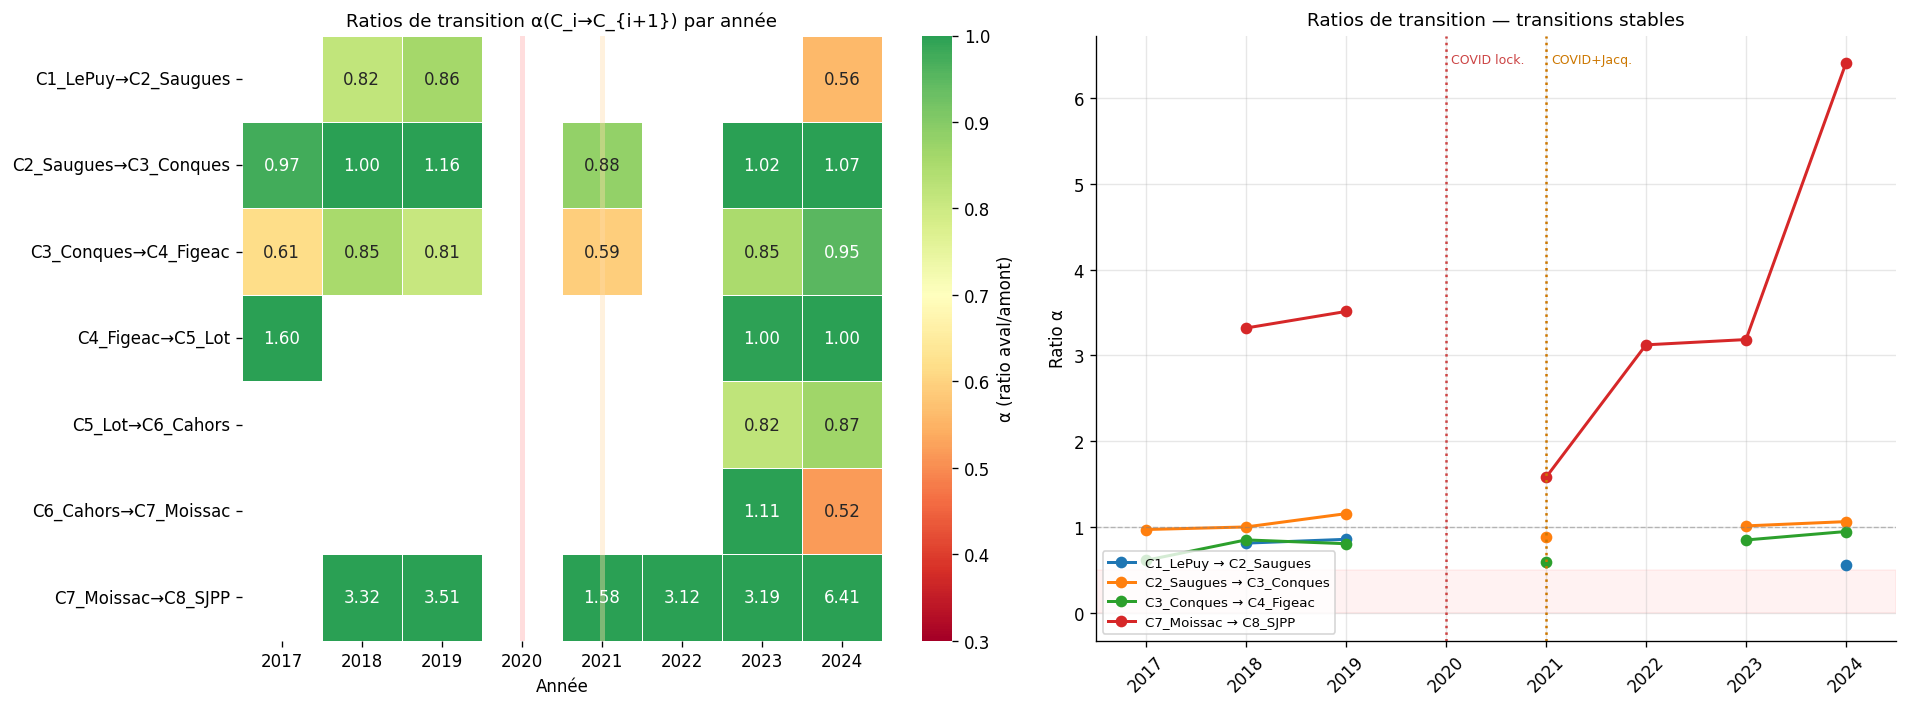

In [6]:
# ── Heatmap des ratios ───────────────────────────────────────────────────────────
fig, (ax_heat, ax_line) = plt.subplots(1, 2, figsize=(16, 6))

# Heatmap
_ratios_plot = df_ratios.copy().astype(float)
# Masquer les ratios RC_05 suspects
_ratios_plot.loc[2022, "C2_Saugues→C3_Conques"] = np.nan

sns.heatmap(
    _ratios_plot.T,
    annot=True, fmt=".2f", cmap="RdYlGn",
    vmin=0.3, vmax=1.0, center=0.7,
    linewidths=0.5, ax=ax_heat,
    cbar_kws={"label": "α (ratio aval/amont)"},
)
ax_heat.set_title("Ratios de transition α(C_i→C_{i+1}) par année", fontsize=11)
ax_heat.set_xlabel("Année")
ax_heat.set_ylabel("")

# Annoter années COVID/Jacquaire sur heatmap
for i, annee in enumerate(ANNEES_PROJET):
    if annee in COVID_ANNEES:
        color = "#ffaaaa" if annee == 2020 else "#ffddaa"
        ax_heat.axvline(i + 0.5, color=color, linewidth=3, alpha=0.4)

# Line plot des ratios stables (hors lacunaires)
stable_transitions = ["C1_LePuy→C2_Saugues", "C2_Saugues→C3_Conques",
                      "C3_Conques→C4_Figeac", "C7_Moissac→C8_SJPP"]
for trans in stable_transitions:
    if trans in df_ratios.columns:
        _r = df_ratios[trans].copy().astype(float)
        if trans == "C2_Saugues→C3_Conques":
            _r.loc[2022] = np.nan  # masquer RC_05
        ax_line.plot(ANNEES_PROJET, _r, marker="o", label=trans.replace("→", " → "), linewidth=1.8)

ax_line.axhspan(0, 0.5, alpha=0.05, color="red")
ax_line.axhline(1.0, color="grey", linestyle="--", linewidth=0.8, alpha=0.5)
ax_line.set_xlim(2016.5, 2024.5)
ax_line.set_xticks(ANNEES_PROJET)
ax_line.tick_params(axis="x", rotation=45)
ax_line.set_ylabel("Ratio α")
ax_line.set_title("Ratios de transition — transitions stables", fontsize=11)
ax_line.legend(fontsize=8, loc="lower left")
ax_line.grid(alpha=0.3)

# Annotations COVID
for annee, label, color in [(2020, "COVID lock.", "#cc4444"),
                             (2021, "COVID+Jacq.", "#cc7700")]:
    ax_line.axvline(annee, color=color, linestyle=":", linewidth=1.5)
    ax_line.text(annee + 0.05, ax_line.get_ylim()[1] * 0.97, label,
                 color=color, fontsize=7.5, va="top")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "nb08_ratios_transition.png", bbox_inches="tight", dpi=150)
plt.show()


In [7]:
# ── Statistiques descriptives des ratios (hors COVID + RC_05) ───────────────────
_mask_excl = ~df_ratios.index.isin([2020, 2021])

print("Statistiques α — hors années COVID (2020, 2021) :")
print("=" * 65)
for col in df_ratios.columns:
    serie = df_ratios.loc[_mask_excl, col].astype(float).dropna()
    if col == "C2_Saugues→C3_Conques":
        serie = serie[serie.index != 2022]  # RC_05
    if len(serie) < 2:
        print(f"  {col:35s}  données insuffisantes ({len(serie)} pt)")
        continue
    print(f"  {col:35s}  mean={serie.mean():.3f}  std={serie.std():.3f}  "
          f"min={serie.min():.3f}  max={serie.max():.3f}  n={len(serie)}")
print()
print("→ Ces valeurs serviront de prior α pour la calibration NB09.")

# ── Signalement des ratios anomaux ────────────────────────────────────────────
print()
print("Ratios α > 1 (anomalies de mesure — non calibrables directement) :")
_excl2 = ~df_ratios.index.isin([2020, 2021])
for col in df_ratios.columns:
    serie = df_ratios.loc[_excl2, col].astype(float).dropna()
    if col == "C2_Saugues->C3_Conques":
        serie = serie[serie.index != 2022]
    if len(serie) >= 2 and serie.mean() > 1.0:
        print(f"  {col:35s}  ᾱ = {serie.mean():.3f}  ← voir §4 pour explication")

print()
print("Ratios calibrables directement (α < 1, hors COVID) :")
for col in df_ratios.columns:
    serie = df_ratios.loc[_excl2, col].astype(float).dropna()
    if col == "C2_Saugues->C3_Conques":
        serie = serie[serie.index != 2022]
    if len(serie) >= 2 and serie.mean() <= 1.0:
        print(f"  {col:35s}  ᾱ = {serie.mean():.3f}  std = {serie.std():.3f}")


Statistiques α — hors années COVID (2020, 2021) :
  C1_LePuy→C2_Saugues                  mean=0.744  std=0.163  min=0.558  max=0.860  n=3
  C2_Saugues→C3_Conques                mean=1.043  std=0.072  min=0.974  max=1.158  n=5
  C3_Conques→C4_Figeac                 mean=0.816  std=0.124  min=0.615  max=0.950  n=5
  C4_Figeac→C5_Lot                     mean=1.198  std=0.346  min=0.997  max=1.597  n=3
  C5_Lot→C6_Cahors                     mean=0.845  std=0.033  min=0.822  max=0.868  n=2
  C6_Cahors→C7_Moissac                 mean=0.814  std=0.419  min=0.518  max=1.110  n=2
  C7_Moissac→C8_SJPP                   mean=3.909  std=1.403  min=3.124  max=6.406  n=5

→ Ces valeurs serviront de prior α pour la calibration NB09.

Ratios α > 1 (anomalies de mesure — non calibrables directement) :
  C2_Saugues→C3_Conques                ᾱ = 1.036  ← voir §4 pour explication
  C4_Figeac→C5_Lot                     ᾱ = 1.198  ← voir §4 pour explication
  C7_Moissac→C8_SJPP                   ᾱ = 3.909  

## 5. Profil mensuel SJPP

Les données SJPP couvrent 2018-2024 avec une dimension unique : `total_mensuel` (84 observations).
Les données antérieures à 2018 ont été exclues pour rester dans la fenêtre projet.

**Saisonnalité structurelle (hors COVID)**

Le profil moyen hors COVID dessine une saison très marquée :
- **Démarrage rapide** : mars (2 000) → avril (7 000-8 500) → mai (10 000-11 000)
- **Pic automnal** : septembre (10 000-11 000) — légèrement supérieur à mai
- **Longue saison** : de mars à octobre, avec juillet-août en "creux relatif" (5 000-8 500)
  probablement lié à la chaleur estivale qui décourage certains pèlerins sur le segment pyrénéen
- **Hiver court** : novembre-décembre, flux marginal (~300-700)

**Lecture des années COVID**

*2020* — Arrêt brutal : mars = 409 (lockdown le 17 mars), avril-juin = 0, réouverture partielle
juillet-octobre. Janvier-février 2020 (428/465) sont anormalement élevés — au-dessus de 2019
(296/359) — ce qui suggère un pic de départs anticipés juste avant la fermeture.

*2021* — Année Jacquaire sous restrictions : flux nul janvier-avril, reprise timide mai (664).
L'Année Sainte produit un effet tardif visible en été-automne (septembre = 5 852) mais
sans retrouver les niveaux pré-COVID — les restrictions internationales ont limité les flux étrangers.


In [8]:
# ── Extraction données SJPP mensuelles ──────────────────────────────────────────
df_sjpp = df[
    (df["_source_key"] == "sjpp_flux")
    & (df["annee"].isin(ANNEES_PROJET))
    & (df["mois"].notna())
    & (df["comptage"].notna())
].copy()

df_sjpp["annee"] = df_sjpp["annee"].astype(int)
df_sjpp["mois"]  = df_sjpp["mois"].astype(int)

print(f"Données SJPP mensuelles : {df_sjpp.shape}")
print()

# Afficher les dimensions disponibles
if "dimension" in df_sjpp.columns:
    print("Dimensions disponibles :")
    dim_counts = df_sjpp.groupby("dimension")["comptage"].count()
    print(dim_counts.to_string())


Données SJPP mensuelles : (84, 37)

Dimensions disponibles :
dimension
total_mensuel    84


In [9]:
# ── Isolation de la dimension flux total ────────────────────────────────────────
# Chercher la dimension 'total' pèlerins — adapter si le nom exact diffère
if "dimension" in df_sjpp.columns:
    _dims = df_sjpp["dimension"].str.lower().unique()
    _total_dim = next(
        (d for d in df_sjpp["dimension"].unique()
         if any(kw in str(d).lower() for kw in ["total", "pèlerin", "pelerin", "flux"])),
        df_sjpp["dimension"].unique()[0]  # fallback : première dimension
    )
    df_sjpp_total = df_sjpp[df_sjpp["dimension"] == _total_dim].copy()
    print(f"Dimension sélectionnée : '{_total_dim}'  — {len(df_sjpp_total)} obs.")
else:
    df_sjpp_total = df_sjpp.copy()
    print("Pas de colonne 'dimension' — toutes les obs SJPP utilisées.")

# ── Pivot mensuel par année ──────────────────────────────────────────────────────
MOIS_LABELS = ["Jan","Fév","Mar","Avr","Mai","Jun","Jul","Aoû","Sep","Oct","Nov","Déc"]

df_sjpp_pivot = df_sjpp_total.pivot_table(
    index="mois", columns="annee", values="comptage", aggfunc="sum"
).reindex(index=range(1, 13))

print("\nFlux mensuel SJPP par année (total pèlerins) :")
print(df_sjpp_pivot.to_string())


Dimension sélectionnée : 'total_mensuel'  — 84 obs.

Flux mensuel SJPP par année (total pèlerins) :
annee   2018   2019  2020  2021   2022   2023   2024
mois                                                
1        292    296   428     0    121    236    207
2        320    359   465     0    231    434    434
3      2,077  1,914   409     0  1,321    373  2,312
4      7,499  8,557     0     0  6,769  1,903 10,118
5     10,837 10,358     0   664  9,743  9,604 10,642
6      7,148  7,694     0 2,425  6,635 10,890  6,889
7      6,173  7,049 2,600 3,589  5,690  6,290  5,214
8      8,320  8,363 2,854 4,810  7,193  5,540  7,286
9     10,189 11,064 2,270 5,852 10,093  7,329 10,435
10     4,135  4,397   988 2,695  4,172 10,132  3,985
11       602    695     0   390    680    607    686
12       289    358     0   161    278    186    243


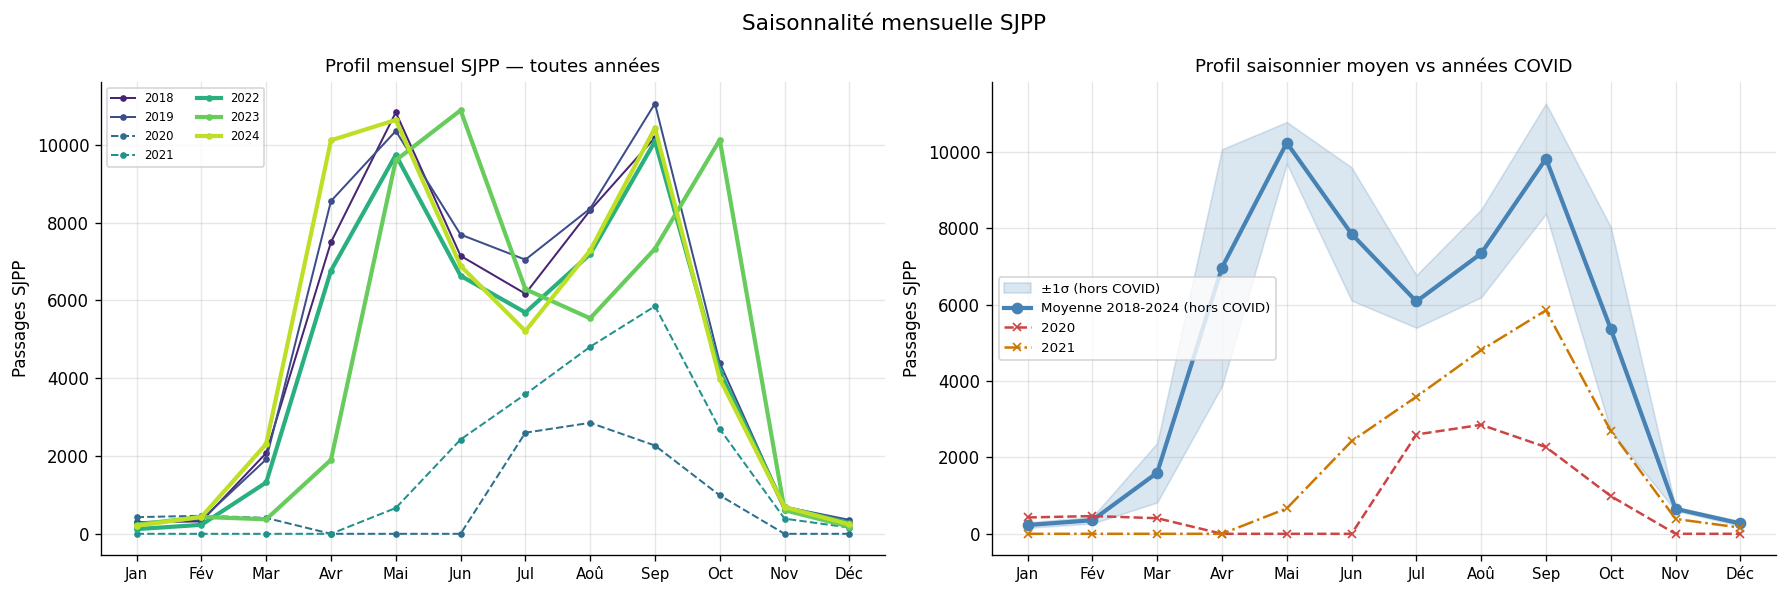

In [10]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# ── Plot 1 : courbes annuelles ────────────────────────────────────────────────
PALETTE = plt.cm.viridis(np.linspace(0.1, 0.9, len(df_sjpp_pivot.columns)))
for j, annee in enumerate(df_sjpp_pivot.columns):
    serie = df_sjpp_pivot[annee]
    lw = 2.5 if annee >= 2022 else 1.2
    ls = "--" if annee in COVID_ANNEES else "-"
    alpha = 1.0 if annee >= 2018 else 0.4
    ax1.plot(range(1, 13), serie, marker="o", markersize=3,
             linewidth=lw, linestyle=ls, alpha=alpha,
             color=PALETTE[j], label=str(annee))

ax1.set_xticks(range(1, 13))
ax1.set_xticklabels(MOIS_LABELS, fontsize=9)
ax1.set_ylabel("Passages SJPP")
ax1.set_title("Profil mensuel SJPP — toutes années", fontsize=11)
ax1.legend(fontsize=7, ncol=2, loc="upper left")
ax1.grid(alpha=0.3)

# ── Plot 2 : profil moyen + enveloppe 2018-2024 ──────────────────────────────
cols_ref = [c for c in df_sjpp_pivot.columns if c >= 2018 and c not in COVID_ANNEES]
if cols_ref:
    _mean = df_sjpp_pivot[cols_ref].mean(axis=1)
    _std  = df_sjpp_pivot[cols_ref].std(axis=1)
    ax2.fill_between(range(1, 13), _mean - _std, _mean + _std,
                     alpha=0.2, color="steelblue", label="±1σ (hors COVID)")
    ax2.plot(range(1, 13), _mean, color="steelblue", linewidth=2.5,
             marker="o", label=f"Moyenne {min(cols_ref)}-{max(cols_ref)} (hors COVID)")

# Superposer 2020 et 2021 pour contraste
for annee, color, ls in [(2020, "#cc4444", "--"), (2021, "#cc7700", "-.")]:
    if annee in df_sjpp_pivot.columns:
        ax2.plot(range(1, 13), df_sjpp_pivot[annee],
                 color=color, linewidth=1.5, linestyle=ls,
                 marker="x", markersize=5, label=str(annee))

ax2.set_xticks(range(1, 13))
ax2.set_xticklabels(MOIS_LABELS, fontsize=9)
ax2.set_ylabel("Passages SJPP")
ax2.set_title("Profil saisonnier moyen vs années COVID", fontsize=11)
ax2.legend(fontsize=8)
ax2.grid(alpha=0.3)

plt.suptitle("Saisonnalité mensuelle SJPP", fontsize=13)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "nb08_sjpp_saisonnalite.png", bbox_inches="tight", dpi=150)
plt.show()


## 6. Extraction des priors comportementaux

Les paramètres comportementaux issus des enquêtes alimentent `PRIORS_TARGET`,
prior pour la calibration NB09.

**Sources mobilisées :**

| Paramètre | Valeur | Source | N | Note |
|-----------|--------|--------|---|------|
| Taux de sectionnisme | 75% | OT Decazeville 2018 | 511 | Locale, GR65 amont Lot |
| Reprise exacte | 19% | ACIR/AFCC 2021 | 247 | Nationale, toutes voies |
| Part GR65 | 55% | AFCC 2021 | 3 565 | Nationale |
| Distance/jour | 25.7 km | AFCC 2021 — P04 | 3 565 | Élevée |
| Durée totale | 27.8 j | AFCC 2021 — P05 | 3 565 | Élevée |
| Primo-cheminants | 51% | AFCC 2021 — P09 | 3 565 | Élevée |

> **Attention sur la simulation §6.2 :** elle utilise C1_LePuy 2024 = 35 850 comme
> dénominateur. Ce chiffre est **biaisé à la hausse** par les usagers locaux du GR65
> (Saint-Christophe-sur-Dolaison, 10 km du Puy). Le nombre réel de pèlerins partant
> pour Santiago est vraisemblablement plus proche de **20 000-22 000** — cohérent
> avec C2_Saugues 2024 = 20 014, point de mesure plus sélectif à 57 km.  
> Les fractions (complétistes, sectionnistes, reprise exacte) sont correctes
> en proportion — seul le niveau absolu est à relativiser.

> **Note :** P08 (Cheminement en autonomie totale = 75%) coïncide numériquement
> avec le taux de sectionnisme mais mesure une chose différente — l'absence de
> prestataire externe, pas la fragmentation du parcours. Ces deux métriques ne
> doivent pas être confondues.


In [11]:
# ── PRIORS_TARGET : paramètres comportementaux pour NB09 ──────────────────────
PRIORS_TARGET: dict[str, dict] = {
    "taux_sectionnisme": {
        "description": "Pèlerins réalisant le chemin par tronçons (non intégral)",
        "valeur": 0.75, "n_estime": 511,
        "source": "OT Decazeville 2018 — GR65 Fonteilles-Livinhac",
    },
    "taux_reprise_exacte": {
        "description": "Sectionnistes reprenant exactement là où ils se sont arrêtés",
        "valeur": 0.19, "n_estime": 247,
        "source": "ACIR/AFCC Synthèse 2021 — toutes voies",
    },
    "part_voie_puy_gr65": {
        "description": "Part des pèlerins empruntant la Voie du Puy (GR65)",
        "valeur": 0.55, "n_estime": 3565,
        "source": "AFCC Synthèse 2021 — p.9",
    },
    "distance_quotidienne_km": {
        "description": "Distance journalière moyenne de marche",
        "valeur": 25.7, "n_estime": 3565,
        "source": "AFCC Synthèse 2021 — P04",
    },
    "duree_totale_jours": {
        "description": "Durée totale moyenne du cheminement (complet)",
        "valeur": 27.8, "n_estime": 3565,
        "source": "AFCC Synthèse 2021 — P05",
    },
    "part_primo_cheminants": {
        "description": "Part des pèlerins réalisant le chemin pour la première fois",
        "valeur": 0.51, "n_estime": 3565,
        "source": "AFCC Synthèse 2021 — P09",
    },
}

# Affichage enrichi depuis df_params (vérification croisée)
if "parametre_id" in df_params.columns and "valeur" in df_params.columns:
    _afcc = df_params[df_params["_source_key"] == "afcc_comportemental"].dropna(subset=["parametre_id"])
    print(f"Paramètres AFCC dans df_params : {len(_afcc)}")
    print(_afcc[["parametre_id", "nom", "valeur", "unite", "fiabilite"]].head(10).to_string(index=False))

print()
print(f"{'Paramètre':35s}  {'Valeur':>10s}  {'N':>6s}  Source")
print("-" * 90)
for key, p in PRIORS_TARGET.items():
    val_str = f"{p['valeur']:.0%}" if p['valeur'] < 2 else f"{p['valeur']:.1f}"
    print(f"  {key:33s}  {val_str:>10s}  {p['n_estime']:>6,}  {p['source']}")


Paramètres AFCC dans df_params : 27
parametre_id                                 nom            valeur       unite fiabilite
         P01                  N total répondants              3565  répondants    ÉLEVÉE
         P02               N points de diffusion               500       sites    ÉLEVÉE
         P03             Période enquête terrain mai-novembre 2021         NaN      INFO
         P04        Distance quotidienne moyenne              25.7     km/jour    ÉLEVÉE
         P05 Durée totale moyenne du cheminement              27.8       jours    ÉLEVÉE
         P06         Durée estimée via Podiensis              29.4       jours  CALCULÉE
         P07           Mode déplacement — à pied                97 pourcentage    ÉLEVÉE
         P08     Cheminement en autonomie totale                75 pourcentage    ÉLEVÉE
         P09               Part primo-cheminants                51 pourcentage    ÉLEVÉE
         P10    Part multi-cheminants (2-5 fois)                37 pourcen

In [12]:
# ── Simulation des implications numériques des priors ───────────────────────────
# Utilise C1_LePuy 2024 si disponible (seule année récente disponible pour C1),
# sinon C8_SJPP 2023 comme référence de flux (hub de convergence toutes voies).

_c1_2024 = df_pivot.loc[2024, "C1_LePuy"] if (2024 in df_pivot.index) else None
_c8_2023 = df_pivot.loc[2023, "C8_SJPP"]  if (2023 in df_pivot.index) else None

if _c1_2024 is not None and not pd.isna(_c1_2024):
    N_ref, ref_label = float(_c1_2024), "C1_LePuy 2024 (proxy départ)"
elif _c8_2023 is not None and not pd.isna(_c8_2023):
    N_ref, ref_label = float(_c8_2023), "C8_SJPP 2023 (hub convergence toutes voies)"
else:
    N_ref, ref_label = None, None

if N_ref:
    completistes   = N_ref * (1 - PRIORS_TARGET["taux_sectionnisme"]["valeur"])
    sectionnistes  = N_ref * PRIORS_TARGET["taux_sectionnisme"]["valeur"]
    reprise_exacte = sectionnistes * PRIORS_TARGET["taux_reprise_exacte"]["valeur"]

    print(f"Simulation à partir de N({ref_label}) = {N_ref:,.0f} passages")
    print()
    print(f"  Complétistes  (25%)           : {completistes:>8,.0f}  → atteignent SJPP cette saison")
    print(f"  Sectionnistes (75%)           : {sectionnistes:>8,.0f}  → s'arrêtent avant SJPP")
    print(f"    dont reprise exacte (19%)   : {reprise_exacte:>8,.0f}  → stock 'en transit' (repartent l'année N+1 ou N+2)")
    print(f"    dont abandon définitif (~6%): {sectionnistes * 0.06:>8,.0f}  → ne reprendront pas (estimation basse)")
    print()
    print("  → Ces décompositions alimentent les taux α, β, γ dans NB09.")
    print(f"  → Note : si référence = C8_SJPP, les flux incluent toutes voies françaises + arrivées espagnoles.")
else:
    print("Aucune donnée de référence disponible pour la simulation.")


Simulation à partir de N(C1_LePuy 2024 (proxy départ)) = 35,850 passages

  Complétistes  (25%)           :    8,962  → atteignent SJPP cette saison
  Sectionnistes (75%)           :   26,888  → s'arrêtent avant SJPP
    dont reprise exacte (19%)   :    5,109  → stock 'en transit' (repartent l'année N+1 ou N+2)
    dont abandon définitif (~6%):    1,613  → ne reprendront pas (estimation basse)

  → Ces décompositions alimentent les taux α, β, γ dans NB09.
  → Note : si référence = C8_SJPP, les flux incluent toutes voies françaises + arrivées espagnoles.


## 7. Synthèse EDA et export

### Résultats clés

**Couverture des séries**

| Compartiment | Couverture | Statut NB09 | Note |
|---|---|---|---|
| C1_LePuy | 3/8 (2018, 2019, 2024) | ⚠ Proxy biaisé | Éco-compteur capte usagers locaux |
| C2_Saugues | 7/8 (manque 2020) | ✅ Utilisable | Masquer 2022 RC_05 |
| C3_Conques | 8/8 complet | ✅ **Référence** | Comptage pèlerin-spécifique |
| C4_Figeac | 6/8 (manque 2020, 2022) | ✅ Utilisable | — |
| C5_Lot | 4/8 (2017, 2022-2024) | ⚠ Contrainte ponctuelle | Démarrage éco-compteur ~2022 |
| C6_Cahors | 2/8 (2023-2024) | ⚠ Contrainte ponctuelle | — |
| C7_Moissac | 6/8 (manque 2020, 2017) | ✅ Utilisable | — |
| C8_SJPP | 8/8 complet | ✅ **Ancre de calibration** | Hub multi-voies, pèlerin-spécifique |

**Points de vigilance pour NB09**

1. **C1_LePuy** — ne pas utiliser comme dénominateur absolu ; préférer C2_Saugues
   comme première mesure pèlerin-fiable sur le GR65 (biais OT + étape Montbonnet documentés en §2)
2. **Transitions α > 1** (C2→C3, C4→C5, C7→C8) — hétérogénéité structurelle documentée,
   nécessitent des contraintes spécifiques dans NB09

**Vue d'ensemble des ratios calibrables**

Les transitions C3→C4 (ᾱ = 0.816) et C5→C6 (ᾱ = 0.845) sont les deux taux de transition
les plus fiables analytiquement. Elles suggèrent une perte de ~16-18% de flux entre
chaque paire de compartiments dans la zone centrale du GR65 (Aveyron/Lot).
Ce taux est cohérent avec un taux de sectionnisme de 75% réparti sur 7 transitions :
0.75^(1/7) ≈ 0.89 par transition en moyenne, soit un profil légèrement plus
favorable que nos mesures directes, ce qui s'explique par des entrées latérales sur le chemin.


In [13]:
# ── Export df_comp → parquet ─────────────────────────────────────────────────────
_out_comp = DATA_PROCESSED / "gr65_compartiments.parquet"
df_comp.to_parquet(_out_comp, index=False, engine="fastparquet")
print(f"✓ gr65_compartiments.parquet → {_out_comp.relative_to(ROOT)}")
print(f"  {df_comp.shape}  |  compartiments : {df_comp['compartiment'].unique().tolist()}")

# ── Export priors → JSON ──────────────────────────────────────────────────────────
_out_priors = DATA_PROCESSED / "priors_comportementaux.json"
with open(_out_priors, "w", encoding="utf-8") as f:
    json.dump(PRIORS_TARGET, f, ensure_ascii=False, indent=2)
print(f"\n✓ priors_comportementaux.json → {_out_priors.relative_to(ROOT)}")

# ── Tableau de bord récapitulatif ────────────────────────────────────────────────
print()
print("=" * 70)
print("  TABLEAU DE BORD NB08")
print("=" * 70)
print(f"  Compartiments GR65 définis   : {len(COMPARTIMENTS)}")
print(f"  Sites actifs dans df_comp    : {df_comp['compartiment'].nunique()}")
print(f"  Fenêtre temporelle           : {ANNEES_PROJET[0]}–{ANNEES_PROJET[-1]}")
print()
print("  Couverture par compartiment :")
for comp_id in COMPARTIMENTS:
    sub = df_comp[(df_comp["compartiment"] == comp_id) & df_comp["comptage"].notna()]
    annees = sorted(sub["annee"].tolist())
    print(f"    {comp_id:14s}  {len(annees):2d}/8 ans  {annees}")
print()
print("  Ratios α moyens (hors COVID) :")
_excl = ~df_ratios.index.isin([2020, 2021])
for col in df_ratios.columns:
    serie = df_ratios.loc[_excl, col].astype(float).dropna()
    if col == "C2_Saugues→C3_Conques":
        serie = serie[serie.index != 2022]
    if len(serie) >= 2:
        print(f"    {col:35s}  ᾱ = {serie.mean():.3f}")
print()
print("  Priors comportementaux :")
for k, v in PRIORS_TARGET.items():
    print(f"    {k:30s}  {v['valeur']:.0%}  (N~{v['n_estime']:,})")
print("=" * 70)


✓ gr65_compartiments.parquet → data\processed\gr65_compartiments.parquet
  (44, 6)  |  compartiments : ['C1_LePuy', 'C2_Saugues', 'C3_Conques', 'C4_Figeac', 'C5_Lot', 'C6_Cahors', 'C7_Moissac', 'C8_SJPP']

✓ priors_comportementaux.json → data\processed\priors_comportementaux.json

  TABLEAU DE BORD NB08
  Compartiments GR65 définis   : 8
  Sites actifs dans df_comp    : 8
  Fenêtre temporelle           : 2017–2024

  Couverture par compartiment :
    C1_LePuy         3/8 ans  [2018, 2019, 2024]
    C2_Saugues       7/8 ans  [2017, 2018, 2019, 2021, 2022, 2023, 2024]
    C3_Conques       8/8 ans  [2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]
    C4_Figeac        6/8 ans  [2017, 2018, 2019, 2021, 2023, 2024]
    C5_Lot           4/8 ans  [2017, 2022, 2023, 2024]
    C6_Cahors        2/8 ans  [2023, 2024]
    C7_Moissac       6/8 ans  [2018, 2019, 2021, 2022, 2023, 2024]
    C8_SJPP          8/8 ans  [2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]

  Ratios α moyens (hors COVID) :
   

---

## Bilan NB08

| Livrable | Statut |
|----------|--------|
| `gr65_compartiments.parquet` | ✅ Exporté — 44 obs, 8 compartiments |
| `priors_comportementaux.json` | ✅ Exporté — 6 paramètres |
| Figures (3 PNG) | ✅ `reports/figures/` |

**Décisions et points de vigilance pour NB09 :**

| Sujet | Décision |
|-------|----------|
| Ancre de calibration | C8_SJPP (8/8, pèlerin-spécifique) |
| Série de référence intermédiaire | C3_Conques (8/8, comptage Sainte-Foy) |
| C1_LePuy | ⚠ Biais éco-compteur — ne pas utiliser comme dénominateur absolu |
| Années à exclure | 2020, 2021 (COVID) + RC_05 2022 (C2, C3) |
| Transitions α > 1 | Contraintes structurelles spécifiques dans NB09 |

**Prochaine étape : NB09 — Modèle à compartiments statique**

Inputs : `gr65_compartiments.parquet` + `priors_comportementaux.json`  
Objectif : calibrer α, β, γ sur les transitions calibrables (C3→C4, C5→C6),
simuler le flux 2017-2024 avec contraintes sur C2→C3 et C7→C8,
valider contre les séries observées C3 et C8.
